Left to do:
1. Import random stuff that we no longer have, like torch OK
2. Build the train and validation datasets OK
3. Create eval function to save best model and get eval loss OK
4. Add evals like BLEU, METEOR, ROUGE, or CIDEr(optional if I read it right)
5. Train it

In [1]:
import kagglehub
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from PIL import Image
import pandas as pd
import os
import json
from sklearn.model_selection import train_test_split
from collections import Counter
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from torch.nn.utils.rnn import pad_sequence
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
# Create the dataset

In [3]:
#download the dataset
#path = kagglehub.dataset_download("nikhil7280/coco-image-caption")
path = "C:\\Users\\Calle\\.cache\\kagglehub\\datasets\\nikhil7280\\coco-image-caption\\versions\\1"
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Calle\.cache\kagglehub\datasets\nikhil7280\coco-image-caption\versions\1


In [4]:
print(os.listdir(path))


['annotations_trainval2014', 'annotations_trainval2017', 'train2014', 'val2017']


In [5]:
#construct the path towards the pictures
train_img_dir = os.path.join(path, "train2014", "train2014")
#construct the path towards the captions
ann_path = os.path.join(
    path,
    "annotations_trainval2014",
    "annotations",
    "captions_train2014.json"
)

In [6]:
#read the jason file
with open(ann_path, "r") as f:
    data = json.load(f)

In [7]:
#associate id of image with the name of the file
image_id_to_file = {
    img["id"]: img["file_name"]
    for img in data["images"]
}

In [8]:
#construct the list images/captions
image_paths = []
captions = []

#we loop in the annotations
for ann in data["annotations"]:
    #we get the name of the image

    img_file = image_id_to_file[ann["image_id"]]

    image_paths.append(os.path.join(train_img_dir, img_file))
    captions.append(ann["caption"])

#at the end image_paths[i] and captions[i] go together

In [9]:

# 70% train
# 30% temporaire (val + test)

train_imgs, temp_imgs, train_caps, temp_caps = train_test_split(
    image_paths,
    captions,
    test_size=0.3,
    random_state=42
)

val_imgs, test_imgs, val_caps, test_caps = train_test_split(
    temp_imgs,
    temp_caps,
    test_size=0.5,
    random_state=42
)

print(f"Number of training samples: {len(train_imgs)}")
print(f"Number of validation samples: {len(val_imgs)}")
print(f"Number of test samples: {len(test_imgs)}")

print("Example image path:", train_imgs[0])
print("Example caption:", train_caps[0])

Number of training samples: 289879
Number of validation samples: 62117
Number of test samples: 62117
Example image path: C:\Users\Calle\.cache\kagglehub\datasets\nikhil7280\coco-image-caption\versions\1\train2014\train2014\COCO_train2014_000000347055.jpg
Example caption: a person near a desk with a keyboard monitor and mouse


In [10]:
#transform words in numbers because networks doesn't understand words 
class Vocabulary:

    def __init__(self, freq_threshold):
        #index->word
        self.itos = {
            0: "<PAD>",
            1: "<SOS>",
            2: "<EOS>",
            3: "<UNK>"
        }
    
        self.stoi = {
            "<PAD>": 0,
            "<SOS>": 1,
            "<EOS>": 2,
            "<UNK>": 3
        }

        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    def tokenizer(self, text):
        return text.lower().split()

    def build_vocabulary(self, sentence_list):

        frequencies = Counter()
        idx = 4

        for sentence in sentence_list:

            for word in self.tokenizer(sentence):

                frequencies[word] += 1

                if frequencies[word] == self.freq_threshold:

                    self.stoi[word] = idx
                    self.itos[idx] = word

                    idx += 1

In [11]:
vocab = Vocabulary(freq_threshold=2) # a word is added if it appears 2 times

vocab.build_vocabulary(train_caps) #vocab built with the training vocab

In [12]:
#to charge the data
class CocoDataset(Dataset):

    def __init__(self, image_paths, captions, vocab, transform=None):

        self.image_paths = image_paths
        self.captions = captions
        self.vocab = vocab
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    #how to get an item
    def __getitem__(self, idx):

        image = Image.open(self.image_paths[idx]).convert("RGB")
        caption = self.captions[idx]

        if self.transform:
            image = self.transform(image)

        # tokenization 
        numericalized = [self.vocab.stoi["<SOS>"]]
        # words-> numbers

        numericalized += [
            self.vocab.stoi.get(word, self.vocab.stoi["<UNK>"])
            for word in caption.split()
        ]

        numericalized.append(self.vocab.stoi["<EOS>"])
        #convert in tensor
        caption_tensor = torch.tensor(numericalized)

        return image, caption_tensor

In [13]:
def get_transform():

    return transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.RandomCrop((299, 299)),
        transforms.ToTensor(),
        transforms.Normalize(
            (0.5, 0.5, 0.5),
            (0.5, 0.5, 0.5)
        )
    ])
    

In [14]:
#create the dataset
train_dataset = CocoDataset(
    train_imgs,
    train_caps,
    vocab,
    transform=get_transform()
)

val_dataset = CocoDataset(
    val_imgs,
    val_caps,
    vocab,
    transform=get_transform()
)
test_dataset = CocoDataset(
    test_imgs,
    test_caps,
    vocab,
    transform=get_transform()
)

Setting up the models

In [26]:
# /root/.cache/kagglehub/datasets/nikhil7280/coco-image-caption/versions/1      <--- path to dataset incase we forget


class EncodeCNN(nn.Module):

    def __init__(self, embed_size, train_CNN=False):

        super(EncodeCNN, self).__init__()

        self.train_CNN = train_CNN

        self.inception = models.inception_v3(
            weights="DEFAULT",
            aux_logits=True
        )
        self.inception.aux_logits = False
        # disable auxiliary classifier
        #self.inception.aux_logits = False
        #self.inception.AuxLogits = None

        # replace final layer
        self.inception.fc = nn.Linear(
            self.inception.fc.in_features,
            embed_size
        )

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):

        features = self.inception(images)

        for name, param in self.inception.named_parameters():

            if "fc.weight" in name or "fc.bias" in name:
                param.requires_grad = True
            else:
                param.requires_grad = self.train_CNN

        return self.dropout(self.relu(features))



class DecodeRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecodeRNN, self).__init__()

        self.embed = nn.Embedding(vocab_size, embed_size)  
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)
    #New forward function
    def forward(self, features, captions):
        # captions: (batch, seq_len)
        # embeddings after embed: (batch, seq_len, embed_size)
        embeddings = self.dropout(self.embed(captions))
        
        # Permute to (seq_len, batch, embed_size) to match LSTM expected input
        embeddings = embeddings.permute(1, 0, 2)
        
        # features: (batch, embed_size) → unsqueeze → (1, batch, embed_size)
        # now both are (seq_len, batch, embed_size) and (1, batch, embed_size) ✓
        embeddings = torch.cat((features.unsqueeze(0), embeddings), dim=0)
        
        hiddens, _ = self.lstm(embeddings)
        output = self.linear(hiddens)
        
        return output[1:]
        
'''
    def forward(self, features, captions):

        embeddings = self.dropout(self.embed(captions))

        embeddings = torch.cat(
            (features.unsqueeze(0), embeddings),
            dim=0
        )

        hiddens, _ = self.lstm(embeddings)

        output = self.linear(hiddens)

        return output  '''
    

class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(CNNtoRNN, self).__init__()

        self.encoderCNN = EncodeCNN(embed_size)
        self.decoderRNN = DecodeRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):

        features = self.encoderCNN(images)
        outputs = self.decoderRNN(features, captions)

        return outputs

    def caption_image(self, image, vocab, max_length=50):

        res_caption = []

        with torch.no_grad():

            x = self.encoderCNN(image).unsqueeze(0)
            states = None

            for _ in range(max_length):

                hiddens, states = self.decoderRNN.lstm(x, states, hiddens)

                output = self.decoderRNN.linear(hiddens.squeeze(0))

                predicted = output.argmax(1)
                print(predicted.shape)

                res_caption.append(predicted.item())

                x = self.decoderRNN.embed(predicted).unsqueeze(0)

                if vocab.itos[predicted.item()] == "<EOS>":
                    break

        return [vocab.itos[idx] for idx in res_caption]

In [16]:
def collate_fn(batch):
    images = []
    captions = []
    for img, cap in batch:
        images.append(img)
        captions.append(cap.detach().clone() if isinstance(cap, torch.Tensor) else torch.as_tensor(cap))

    images   = torch.stack(images, dim=0)
    captions = pad_sequence(
        captions,
        batch_first=True,
        padding_value=0
    )
    return images, captions

In [17]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn   
)

In [18]:
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False,      # no need to shuffle for evaluation
    num_workers=0,
    collate_fn=collate_fn
)

In [19]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [20]:
i = 0
print("Inspecting training data batches:")
for imgs, captions in train_loader:
    print("examining batch", i)
    if i == 2:
        break
    print("Image batch shape:", imgs.shape)
    print("Caption batch shape:", captions.shape)
    print(captions)
    i+=1

Inspecting training data batches:
examining batch 0
Image batch shape: torch.Size([32, 3, 299, 299])
Caption batch shape: torch.Size([32, 20])
tensor([[    1,     4,    23,    76,    12,  1290,    13,     4,   138,   117,
             2,     0,     0,     0,     0,     0,     0,     0,     0,     0],
        [    1,     3,   118,    10,     4,   538,    76,  1173,  4276,   151,
             4,  5499,     2,     0,     0,     0,     0,     0,     0,     0],
        [    1,     3,    17,   284,    13,     4,  3505,  2023,  1325,     2,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0],
        [    1,     4,   213,     5,   449,     4,    45,   142,    21,     4,
            55,     2,     0,     0,     0,     0,     0,     0,     0,     0],
        [    1,     3,    23,    62,    13,    11,    36,     6,     4,   453,
           585,     2,     0,     0,     0,     0,     0,     0,     0,     0],
        [    1,     3,  1004,     6,    98,  4111,  1217,     

Training code

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for imgs, captions in loader:

            imgs = imgs.to(device)
            captions = captions.to(device)

            # input / target (teacher forcing)
            inputs = captions[:, :-1]
            targets = captions[:, 1:]
            
            outputs = model(imgs, inputs)

            loss = criterion(
                outputs.reshape(-1, outputs.shape[2]),
                targets.reshape(-1)
            )
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    print(f"  Val Loss : {avg_loss:.4f}")

    model.train()
    return avg_loss

from torchtext.data.metrics import bleu_score
def eval_bleu(model, loader, vocab, device):        #Need to run the block containing the decode_caption function before this one for it to work, see farther down 
    model.eval()
    candidates = []
    references = []

    for image, caption_tensor in loader:
        
        image_input = image.unsqueeze(0).to(device)
        tokens = model.caption_image(image_input, vocab)
        predicted_words = decode_caption(tokens, vocab).split()
        candidates.append(predicted_words)

        # reference caption
        ref_words = decode_caption(caption_tensor.tolist(), vocab).split()
        references.append([ref_words])  

    return bleu_score(candidates, references)


In [ ]:
def train():
    SAVE_PATH = r"C:\Users\Calle\Desktop\Kod\D7047E\Advanced-deep-learning\Lab3\BestModel.pth"  #Change this to the path we want to save it in
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    embed_size = 256
    hidden_size = 256
    vocab_size = len(train_dataset.vocab)
    num_layers = 1
    lr = 3e-4
    num_epochs = 100
    best_loss = float("inf")
    logging = False
    model = CNNtoRNN(
        embed_size,
        hidden_size,
        vocab_size,
        num_layers
    ).to(device)

    criterion = nn.CrossEntropyLoss(
        ignore_index=train_dataset.vocab.stoi["<PAD>"]
    )

    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()

    for epoch in range(num_epochs):

        total_loss = 0

        for idx, (imgs, captions) in enumerate(train_loader):
            imgs     = imgs.to(device)
            captions = captions.to(device)

            outputs = model(imgs, captions[:, :-1])   # input tokens
            target  = captions[:, 1:]                 # target tokens

            loss = criterion(
                outputs.reshape(-1, outputs.shape[2]),
                target.reshape(-1)
            )

            optimizer.zero_grad()
            loss.backward(loss)
            optimizer.step()

            total_loss += loss.item()
            
        eval_loss = evaluate(model, val_loader, criterion, device)
        bleu = eval_bleu(model, val_loader, vocab, device)
        loss_total = total_loss / len(train_loader)
        if eval_loss < best_loss:
            best_loss = eval_loss
            torch.save({                            #Lets us load the model later like this:checkpoint = torch.load("best_model.pth", map_location=device), model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device),model.load_state_dict(checkpoint["model"]), optimizer.load_state_dict(checkpoint["optimizer"]) 
                "epoch":      epoch + 1,
                "step":       idx,
                "model":      model.state_dict(),
                "optimizer":  optimizer.state_dict(),
                "val_loss":   eval_loss,
                "vocab":      vocab,
            }, SAVE_PATH)
            print(f"Saved best model (val_loss={eval_loss:.4f})")
        if logging:
            wandb.log({"Train Loss": loss_total, "Val Loss": eval_loss, "epoch": epoch+1, "Bleu-4": bleu})
        else:
            print(f"Epoch {epoch+1} Loss: {loss_total:.4f} Val Loss: {eval_loss:.4f}")
        print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

    return model

In [ ]:
'''import wandb
wandb.init(project="Lab3", name="Test_run2", config={
    "learning_rate": 3e-4,
    "batch_size": 32,
    "epochs": 10,
})'''
print("Starting training...")
model = train()

Starting training...
  Val Loss : 5.5262
Saved best model (val_loss=5.5262)
Epoch 1 Loss: 5.4107 Val Loss: 5.5262
Epoch 1 Loss: 50601.1081
  Val Loss : 5.5219
Saved best model (val_loss=5.5219)
Epoch 2 Loss: 5.4986 Val Loss: 5.5219
Epoch 2 Loss: 50327.5342
  Val Loss : 5.5213
Saved best model (val_loss=5.5213)
Epoch 3 Loss: 5.7977 Val Loss: 5.5213
Epoch 3 Loss: 50300.8678
  Val Loss : 5.5200
Saved best model (val_loss=5.5200)
Epoch 4 Loss: 5.4050 Val Loss: 5.5200
Epoch 4 Loss: 50286.0019


In [ ]:
#predict images

In [103]:
checkpoint = torch.load("/Lab3/Models/BestModel.pth", map_location=device)

In [121]:
model = CNNtoRNN(
    embed_size,
    hidden_size,
    len(checkpoint["vocab"]),
    num_layers
).to(device)

In [122]:
model.load_state_dict(checkpoint["model"])

<All keys matched successfully>

In [123]:
model.eval()

CNNtoRNN(
  (encoderCNN): EncodeCNN(
    (inception): Inception3(
      (Conv2d_1a_3x3): BasicConv2d(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      )
      (Conv2d_2a_3x3): BasicConv2d(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      )
      (Conv2d_2b_3x3): BasicConv2d(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      )
      (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
      (Conv2d_3b_1x1): BasicConv2d(
        (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=Tr

In [107]:
print(type(model))

<class '__main__.CNNtoRNN'>


In [113]:
def decode_caption(tokens, vocab):

    words = []

    for token in tokens:

        # if it's a word
        if isinstance(token, str):
            words.append(token)
            continue

        # if it's an index
        word = vocab.itos[token]

        if word == "<EOS>":
            break

        if word not in ["<SOS>", "<PAD>"]:
            words.append(word)

    return " ".join(words)

In [114]:
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

In [129]:
def predict_caption(image_path, model, vocab):

    image = Image.open(image_path).convert("RGB")

    display_image = image

    image = transform(image).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        # génération caption
        tokens = model.caption_image(image, vocab)

    caption = decode_caption(tokens, vocab)

    # affichage
    plt.imshow(display_image)
    plt.title(caption)
    plt.axis("off")
    plt.show()

    return caption

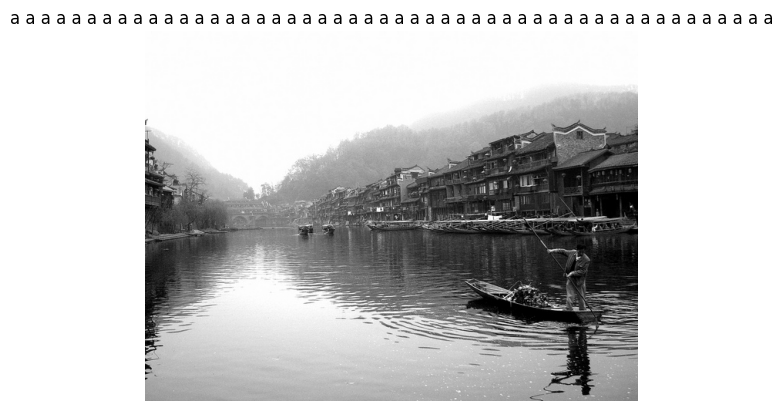

'a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a'

In [130]:
predict_caption(train_imgs[1], model, checkpoint["vocab"])

In [66]:
for imgs, caps in train_loader:
    print(imgs.shape)
    print(caps.shape)
    break

torch.Size([32, 3, 299, 299])
torch.Size([32, 18])


In [65]:
print(f"Steps per epoch: {len(train_loader)}")
print(f"Steps per epoch: {len(val_loader)}")
wandb.finish()

Steps per epoch: 10353
Steps per epoch: 2589


Train Loss,▆▁█▅▇▅▅▅▂▄▅▄█▅▃▅▇▇█▄▃▅█▂▃▄▄▇▄▅▇▆▆▆▃▃▅▂▂▅
Val Loss,█▆▆▄▃▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇████
step,▁▄▆▇█▇▁▂▄▅▂▃▅▅▆▁▃▅█▂▅▅█▂▂▅▆▇█▁▄▅▇▇█▂▃▇▂▅
Train Loss,5.53529
Val Loss,5.52323
epoch,10
step,10000


In [64]:
import os
os.makedirs("/Lab3/Models", exist_ok=True)